# Brest Cancer Dataset

In [1]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import os
import h5py

In [2]:
# https://scikit-learn.org/stable/datasets/index.html#breast-cancer-dataset

X, y = load_breast_cancer(return_X_y= True)
print ('X.shape= ', X.shape)
print ('y.shape= ', y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)


X.shape=  (569, 30)
y.shape=  (569,)


In [3]:
# YOUR_CODE.  Preproces data, train classifier and evaluate the perfromance on train and test sets 
# START_CODE 

clf= Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        solver='lbfgs',
        max_iter=1000,
        hidden_layer_sizes=(4, 6, 10),
        activation='relu',
    ))
])

clf.fit(X_train, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train, y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test, y_test)))
# END_CODE 

train accuracy= 99.531%
test accuracy= 97.902%


# Signs dataset

In [4]:
# signs data set (fingers)
def load_dataset():
    fn =  os.path.join('./data' , 'train_signs.h5')
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn =  os.path.join('./data' , 'test_signs.h5')
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    y_train = y_train.reshape((1, y_train.shape[0]))
    y_test = y_test.reshape((1, y_test.shape[0]))
    
    return X_train, y_train, X_test, y_test, classes

In [5]:
X_train, y_train, X_test, y_test, classes = load_dataset()
y_train = y_train.ravel()
y_test = y_test.ravel()
print ('X_train.shape=', X_train.shape)
print ('X_test.shape=', X_test.shape)
print ('y_train.shape=', y_train.shape)
print ('y_test.shape=', y_test.shape)

X_train.shape= (1080, 64, 64, 3)
X_test.shape= (120, 64, 64, 3)
y_train.shape= (1080,)
y_test.shape= (120,)


In [6]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None: 
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows): 
        for j in range (n_cols):
            index = n_rows*i+j           
            ax = plt.subplot(n_rows,n_cols,index+1) 
            plt.imshow(X[indices[index]])
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')

    plt.tight_layout(h_pad=1)

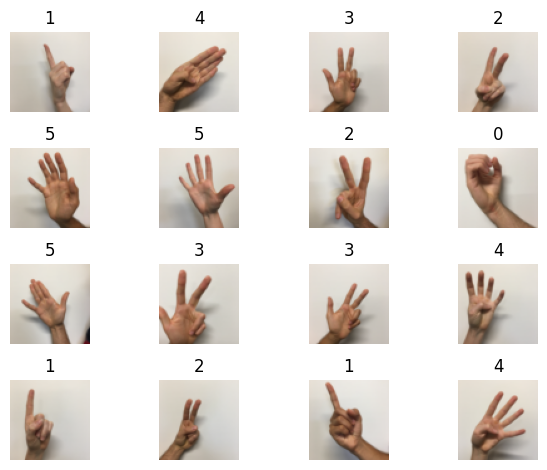

In [7]:
plt.figure()

display_samples_in_grid(X_train, n_rows=4, y= y_train)

In [17]:
# YOUR_CODE.  Preproces data
# START_CODE 

X_train_reshape = X_train.reshape(X_train.shape[0], -1)
X_test_reshape = X_test.reshape(X_test.shape[0], -1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshape)
X_test_scaled = scaler.transform(X_test_reshape)
# END_CODE     

print ("number of training examples = " + str(X_train_scaled.shape[1]))
print ("number of test examples = " + str(X_test_scaled.shape[1]))
print ("X_train_scaled shape: " + str(X_train_scaled.shape))

print ("X_test_scaled shape: " + str(X_test_scaled.shape))

number of training examples = 12288
number of test examples = 12288
X_train_scaled shape: (1080, 12288)
X_test_scaled shape: (120, 12288)


In [9]:
# YOUR_CODE.  Train classifier and evaluate the perfromance on train and test sets 
# START_CODE 
clf= MLPClassifier(
    solver='lbfgs',
    hidden_layer_sizes=(50,50),
    random_state=40,
).fit(X_train_scaled, y_train)

print("train accuracy= {:.3%}".format(clf.score(X_train_scaled,y_train)))
print("test accuracy= {:.3%}".format(clf.score(X_test_scaled,y_test)))
# END_CODE     

train accuracy= 100.000%
test accuracy= 90.833%


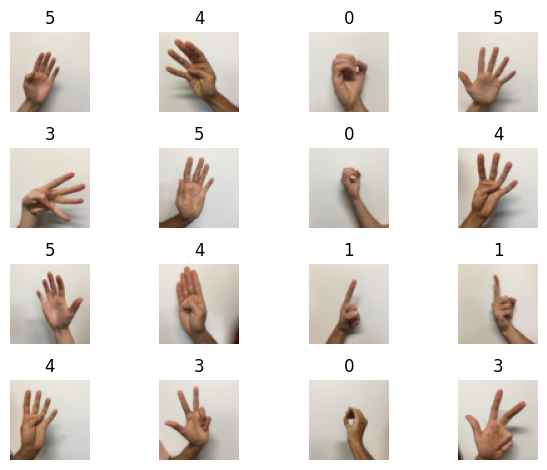

In [10]:
plt.figure()
predicted = clf.predict(X_test_scaled)
display_samples_in_grid(X_test, n_rows=4, y= predicted)

In [11]:
from sklearn.svm import SVC

In [18]:
clf = SVC(C=10, kernel='rbf', gamma=0.001).fit(X_train_scaled, y_train)
print("train accuracy= {:.3%}".format(clf.score (X_train_scaled, y_train)))
print("test accuracy= {:.3%}".format(clf.score (X_test_scaled, y_test)))

train accuracy= 100.000%
test accuracy= 65.000%


The training time takes approximately 7 minutes which is much longer than in the MLP-based model.
The accuracy in the training and test datasets is very different which means that the model is overfitting. For better result wa can use linear kernel instead of RBF kernel. It will make the model training faster and will be better test accuracy.